In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('main.ipynb'), '..')))

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from astropy.wcs import WCS
import pandas as pd
from scipy import interpolate
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Input
from tensorflow.keras.optimizers import Adam

In [3]:
from utils.utilitas import inputx_outputy
from utils.arsitektur import StarNet
from utils.kma_method import KomodoMlipirAlgorithm
from utils.pre_processing import interpolate_nan, normalize_flux_median, standarize_output,decode_pred,mean_std
import seaborn as sns

In [4]:
#dapatkan data x dan y dimana x adalah flux dan y adalah vektor teff, logg, feh dan vin sin 1
"""
query
SELECT TOP 5000 *
FROM apogeeStar at INNER JOIN 
aspcapStar asr ON at.apogee_id = asr.apogee_id
where at.starflag = 0 
and at.vscatter < 1 and at.rv_logg != -9999 and at.SNR > 200 and asr.aspcapflag =0
and asr.vsini != -9999 and at.telescope = 'apo25m' and m_h != -9999

"""
name_file_1 = 'sdss_spectra_data_bintang_apogee.csv'
name_file_2 = 'file_id.csv'
folder_path = 'spectra_images_apogee'

x, y, wavelength = inputx_outputy(name_file_1, name_file_2, folder_path,untuk='train')
x_val, y_val, wavelength_val = inputx_outputy(name_file_1, name_file_2, folder_path, untuk='test')
#interpolasi nilai nan
for i in range(len(x)):
    x[i] = interpolate_nan(x[i])
    x[i] = normalize_flux_median(x[i],wavelength[i])

for i in range(len(x_val)):
    x_val[i] = interpolate_nan(x_val[i])
    x_val[i] = normalize_flux_median(x_val[i],wavelength_val[i])
    
mean_y,std_y = mean_std(y)   
y = standarize_output(y)

#split data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
#X_train_cnn, X_test_cnn,y_train_cnn,y_test_cnn = train_test_split(X_train,y_train, test_size=0.2,random_state=22)

In [5]:
# komodo n = 5
komodo_5 = [0.63479505, 0.09083289, 0.42500061, 0.25655968, 0.803561,   0.5574774,
 0.84808518, 0.85347074, 0.55757087, 0.44375022, 0.2768684,  0.07376918,
 0.49028438, 0.54182711, 0.63778676, 0.84474267]

#komodo n = 10
komodo_10 = [0.43803341, 0.79255546, 0.25906532, 0.42487103, 0.22479651, 0.66282992,
 0.07376419, 0.61606665, 0.37278885, 0.86455141, 0.33717008, 0.66282992,
 0.77520349, 0.53536994, 0.33717008, 0.16457245]

#komodo = 15
komodo_15 = [0.05668635, 0.48560174, 0.48922369, 0.46012899, 0.46196719, 0.68169073,
 0.24546223, 0.51542717, 0.45423118, 1.,         0.46380473, 0.29096663,
 0.4899689,  0.47045753, 0.47757844, 0.53420781]

In [6]:
starnet_5 = StarNet(X_train,y_train,X_test,y_test)
starnet_10 = StarNet(X_train,y_train,X_test,y_test)
starnet_15 = StarNet(X_train,y_train,X_test,y_test)
#decode
kom_5_parameter = starnet_5.decode(komodo_5)
kom_10_parameter = starnet_10.decode(komodo_10)
kom_15_parameter = starnet_15.decode(komodo_15)
 
print(f'Parameter Komodo n = 5 :{kom_5_parameter}')
print(f'Parameter Komodo n = 10 :{kom_10_parameter}')
print(f'Parameter Komodo n = 15 :{kom_15_parameter}')

Parameter Komodo n = 5 :[40, 16, 'tanh', 'tanh', 'glorot_normal', 'orthogonal', 7, 'elu', 'sigmoid', 'tanh', 'random_uniform', 'zeros', 'variance_scaling', 0.0001, 81, 32]
Parameter Komodo n = 10 :[32, 48, 'tanh', 'tanh', 'random_normal', 'lecun_normal', 2, 'sigmoid', 'tanh', 'elu', 'truncated_normal', 'lecun_normal', 'glorot_normal', 0.0001, 66, 1]
Parameter Komodo n = 15 :[16, 32, 'tanh', 'tanh', 'variance_scaling', 'lecun_uniform', 3, 'sigmoid', 'tanh', 'selu', 'variance_scaling', 'random_uniform', 'variance_scaling', 0.0001, 73, 8]


In [7]:
#train komodo_5
starnet_5.arsitektur_start_net(X_train, y_train, X_test, y_test, kom_5_parameter[0],kom_5_parameter[1],kom_5_parameter[2],kom_5_parameter[3],kom_5_parameter[4],kom_5_parameter[5],kom_5_parameter[6],kom_5_parameter[7],kom_5_parameter[8],kom_5_parameter[9],kom_5_parameter[10],kom_5_parameter[11],kom_5_parameter[12],kom_5_parameter[13],kom_5_parameter[14],kom_5_parameter[15])
hist_5 = starnet_5.history
model_5 = starnet_5.model

Epoch 1/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 216ms/step - loss: 1.0738 - val_loss: 0.9092
Epoch 2/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 182ms/step - loss: 1.0586 - val_loss: 0.9090
Epoch 3/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 180ms/step - loss: 0.9748 - val_loss: 0.9120
Epoch 4/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 181ms/step - loss: 1.0176 - val_loss: 0.9020
Epoch 5/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - loss: 0.9660 - val_loss: 0.9066
Epoch 6/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 182ms/step - loss: 1.0478 - val_loss: 0.9031
Epoch 7/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step - loss: 0.9626 - val_loss: 0.9241
Epoch 8/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 204ms/step - loss: 0.9686 - val_loss: 0.9112
Epoch 9/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 195ms/step - loss: 0.9326 - val_loss: 0.9059
Epoch 10/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 195ms/step - loss: 1.1280 - val_loss: 0.9019
Epoch 11/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - loss: 0.9323 - val_loss: 0.9089
Epoch 12/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step

In [8]:
#train komodo_10
starnet_10.arsitektur_start_net(X_train, y_train, X_test, y_test, kom_10_parameter[0],kom_10_parameter[1],kom_10_parameter[2],kom_10_parameter[3],kom_10_parameter[4],kom_10_parameter[5],kom_10_parameter[6],kom_10_parameter[7],kom_10_parameter[8],kom_10_parameter[9],kom_10_parameter[10],kom_10_parameter[11],kom_10_parameter[12],kom_10_parameter[13],kom_10_parameter[14],kom_10_parameter[15])
hist_10 = starnet_10.history
model_10 = starnet_10.model

Epoch 1/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 122s 189ms/step - loss: 1.0395 - val_loss: 0.5471
Epoch 2/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 118s 187ms/step - loss: 0.5230 - val_loss: 0.4425
Epoch 3/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 118s 187ms/step - loss: 0.4172 - val_loss: 0.3118
Epoch 4/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 141s 184ms/step - loss: 0.3057 - val_loss: 0.2568
Epoch 5/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 118s 187ms/step - loss: 0.2382 - val_loss: 0.2365
Epoch 6/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 119s 188ms/step - loss: 0.2752 - val_loss: 0.2262
Epoch 7/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 118s 187ms/step - loss: 0.2167 - val_loss: 0.2198
Epoch 8/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 141s 185ms/step - loss: 0.2596 - val_loss: 0.2049
Epoch 9/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 118s 187ms/step - loss: 0.2254 - val_loss: 0.1963
Epoch 10/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 119s 188ms/step - loss: 0.2331 - val_loss: 0.1893
Epoch 11/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 120s 189ms/step - loss: 0.2020 - val_loss: 0.1930
Epoch 12

In [9]:
#train komodo_15
starnet_15.arsitektur_start_net(X_train, y_train, X_test, y_test, kom_15_parameter[0],kom_15_parameter[1],kom_15_parameter[2],kom_15_parameter[3],kom_15_parameter[4],kom_15_parameter[5],kom_15_parameter[6],kom_15_parameter[7],kom_15_parameter[8],kom_15_parameter[9],kom_15_parameter[10],kom_15_parameter[11],kom_15_parameter[12],kom_15_parameter[13],kom_15_parameter[14],kom_15_parameter[15])
hist_15 = starnet_15.history
model_15 = starnet_15.model

Epoch 1/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 171ms/step - loss: 1.1093 - val_loss: 0.9069
Epoch 2/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 19s 159ms/step - loss: 1.0297 - val_loss: 0.8632
Epoch 3/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 168ms/step - loss: 0.9070 - val_loss: 0.5887
Epoch 4/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step - loss: 0.6640 - val_loss: 0.5446
Epoch 5/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 167ms/step - loss: 0.5710 - val_loss: 0.5302
Epoch 6/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 169ms/step - loss: 0.5478 - val_loss: 0.4414
Epoch 7/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 160ms/step - loss: 0.4505 - val_loss: 0.4224
Epoch 8/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 161ms/step - loss: 0.4121 - val_loss: 0.3551
Epoch 9/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 167ms/step - loss: 0.3519 - val_loss: 0.3021
Epoch 10/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - loss: 0.2780 - val_loss: 0.2855
Epoch 11/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - loss: 0.2428 - val_loss: 0.2321
Epoch 12/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 14

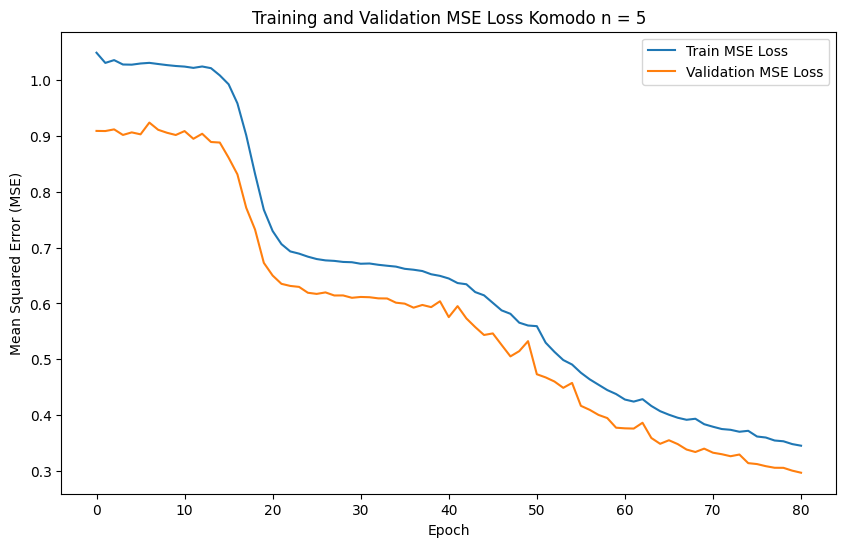

In [10]:
# plot train_valid komodo 5

plt.figure(figsize=(10, 6))
plt.plot(hist_5.history['loss'], label='Train MSE Loss')
plt.plot(hist_5.history['val_loss'], label='Validation MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Validation MSE Loss Komodo n = 5')
plt.legend()
plt.show()

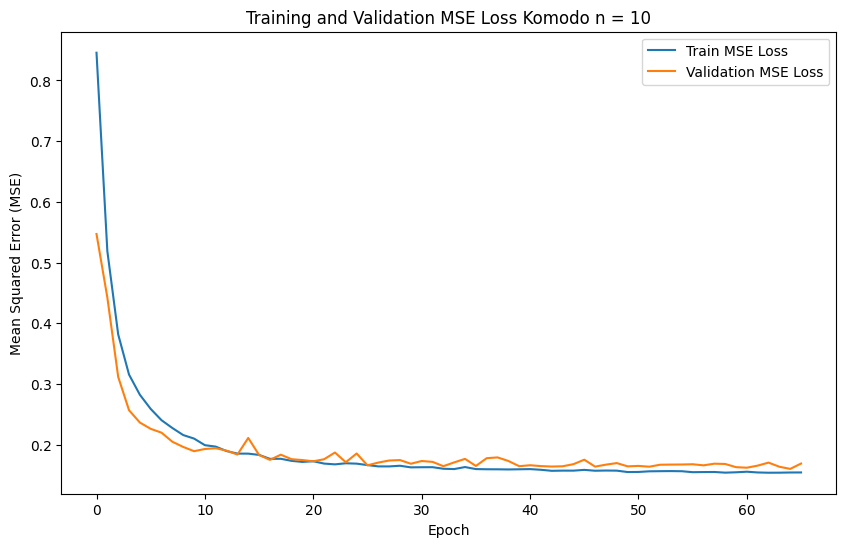

In [11]:
# plot train_valid komodo 10

plt.figure(figsize=(10, 6))
plt.plot(hist_10.history['loss'], label='Train MSE Loss')
plt.plot(hist_10.history['val_loss'], label='Validation MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Validation MSE Loss Komodo n = 10')
plt.legend()
plt.show()

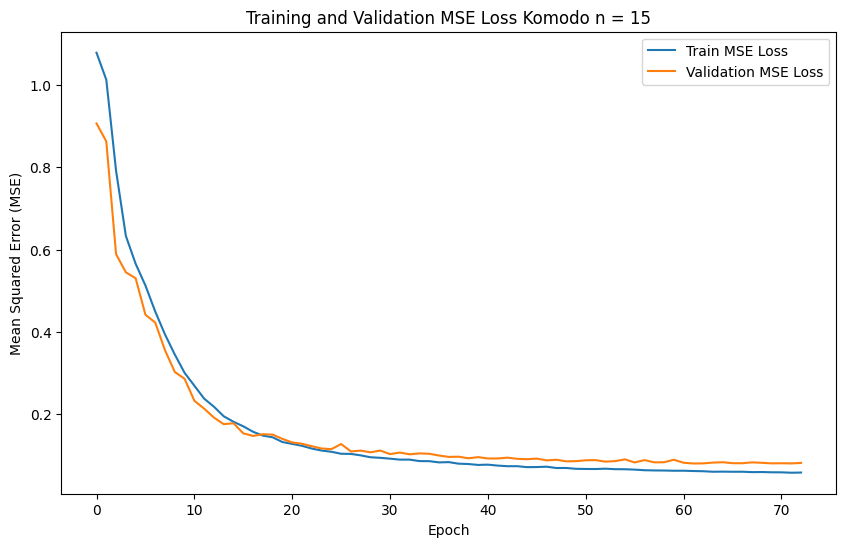

In [12]:
# plot train_valid komodo 15

plt.figure(figsize=(10, 6))
plt.plot(hist_15.history['loss'], label='Train MSE Loss')
plt.plot(hist_15.history['val_loss'], label='Validation MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Validation MSE Loss Komodo n = 15')
plt.legend()
plt.show()

In [13]:
#hasil prediksi
y_pred_5 = model_5.predict(x_val)
y_pred_10 = model_10.predict(x_val)
y_pred_15 = model_15.predict(x_val)

y_pred_5 = decode_pred(y_pred_5,mean_y,std_y)
y_pred_10 = decode_pred(y_pred_10,mean_y,std_y)
y_pred_15 = decode_pred(y_pred_15,mean_y,std_y)

99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step


In [ ]:
#nilai residual
residu_5 = y_pred_5 - y_val
residu_10 = y_pred_10 - y_val
residu_15 = y_pred_15 - y_val

mean_aktual = np.mean(y_val, axis = 0)

ss_5 = np.sum((residu_5 - mean_aktual)**2)
ss_10 = np.sum((residu_10 - mean_aktual)**2)
ss_15 = np.sum((residu_15 - mean_aktual)**2)

In [ ]:
#nilai mse,rmse dan r^2
mse_5 = np.mean(np.square(residu_5))
mse_10 = np.mean(np.square(residu_10))
mse_15 = np.mean(np.square(residu_15))

rmse_5 = np.sqrt(mse_5)
rmse_10 = np.sqrt(mse_10)
rmse_15 = np.sqrt(mse_15)

r2_5 = 1 - (np.sum(np.square(residu_5)) / ss_5)
r2_10 = 1 - (np.sum(np.square(residu_10)) / ss_10)
r2_15 = 1 - (np.sum(np.square(residu_15)) / ss_15)



print(f'MSE Komodo n = 5 : {mse_5}')
print(f'MSE Komodo n = 10 : {mse_10}')
print(f'MSE Komodo n = 15 : {mse_15}')

print(f'RMSE Komodo n = 5 : {rmse_5}')
print(f'RMSE Komodo n = 10 : {rmse_10}')
print(f'RMSE Komodo n = 15 : {rmse_15}')

print(f'R^2 Komodo n = 5 : {r2_5}')
print(f'R^2 Komodo n = 10 : {r2_10}')
print(f'R^2 Komodo n = 15 : {r2_15}')


MSE Komodo n = 5 : 10490.35721664174
MSE Komodo n = 10 : 7524.108801363734
MSE Komodo n = 15 : 3403.455090989927
RMSE Komodo n = 5 : 102.42244488705461
RMSE Komodo n = 10 : 86.74162092884669
RMSE Komodo n = 15 : 58.33913858628637


In [16]:
#plot residu SNR > 200

def plot_residu(residu,y_true,parameter):
    if parameter == 'teff':
        res = [teff[0] for teff in residu]
        y = [teff_true[0] for teff_true in y_true]
        kata = '$T_{eff}$'
        kata2 = '$\Delta T_{eff}$'
    elif parameter == 'log_g':
        res = [logg[1] for logg in residu]
        y = [logg_true[1] for logg_true in y_true]
        kata = '$log g$'
        kata2 = '$\Delta log g$'
    elif parameter == 'vsini':
        res = [vsini[2] for vsini in residu]
        y = [vsini_true[2] for vsini_true in y_true]
        kata = '$v sin i$'
        kata2 = '$\Delta v sin i$' 
    else:
        res = [metal[3] for metal in residu]
        y = [metal_true[3] for metal_true in y_true]
        kata = '$M/H$'
        kata2 = '$\Delta M/H$'
    
    res = np.array(res)
    y = np.array(y)
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [3, 1]})


    ax[0].scatter(y, res, color='blue', s=10, alpha=0.7)
    ax[0].axhline(0, color='gray', linestyle='--', linewidth=1)
    ax[0].set_xlabel(f'ASPCAP DR17 {kata}')
    ax[0].set_ylabel(f'{kata2} (StarNet - DR17)')

    # Hitung rata-rata dan standar deviasi residual
    mean_residual = np.mean(res)
    std_residual = np.std(res)
    
    # Hitung posisi tengah pada sumbu x dan y
    x_center = (y.min() + y.max()) / 2  # Posisi tengah sumbu x
    y_center = 0  # Agar teks berada dekat dengan garis nol pada sumbu y
    
    # Tambahkan teks di tengah
    ax[0].text(x_center, y_center, f"$\\bar{{m}}$={mean_residual:.2f}, $s$={std_residual:.2f}",
               fontsize=10, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))

    # Histogram distribusi residual di kanan
    sns.histplot(res, bins=30, kde=True, ax=ax[1], color='blue', orientation='horizontal')
    ax[1].set_ylabel('')
    ax[1].set_xlabel('Density')
    ax[1].axhline(0, color='gray', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:13: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:23: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:13: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:23: SyntaxWarning: invalid escape sequence '\D'
C:\Users\itdev.support22\AppData\Local\Temp\ipykernel_12492\3810704085.py:8: SyntaxWarning: invalid escape sequence '\D'
  kata2 = '$\Delta T_{eff}$'
C:\Users\itdev.support22\AppData\Local\Temp\ipykernel_12492\3810704085.py:13: SyntaxWarning: invalid escape sequence '\D'
  kata2 = '$\Delta log g$'
C:\Users\itdev.support22\AppData\Local\Temp\ipykernel_12492\3810704085.py:18: SyntaxWarning: invalid escape sequence '\D'
  kata2 = '$\Delta v sin i$'
C:\Users\itdev.support22\AppData\Local\Temp\ipykernel_12492\3810704085.py:23: SyntaxWarning: invalid escape sequence '\D'
  kata2 = '$\Delta M/H

In [ ]:
#fungsi mse rsme
def mse_rsme(residu,parameter):
    
    if parameter == 'teff':
        res = [teff[0] for teff in residu]
        mean_aktual = np.mean(np.array([teff[0] for teff in y_val]))
       
    elif parameter == 'log_g':
        res = [logg[1] for logg in residu]
        mean_aktual = np.mean(np.array([logg[1] for logg in y_val]))
        
    elif parameter == 'vsini':
        res = [vsini[2] for vsini in residu]
        mean_aktual = np.mean(np.array([vsini[2] for vsini in y_val]))
        
    else:
        res = [metal[3] for metal in residu]
        mean_aktual = np.mean(np.array([metal[3] for metal in y_val]))
    
    res = np.square(np.array(res))
    mse = np.mean(res)
    rsme = np.sqrt(mse)
    r2 = 1 - (np.sum(res) / np.sum((res - mean_aktual)**2))

    return mse,rsme,r2
        

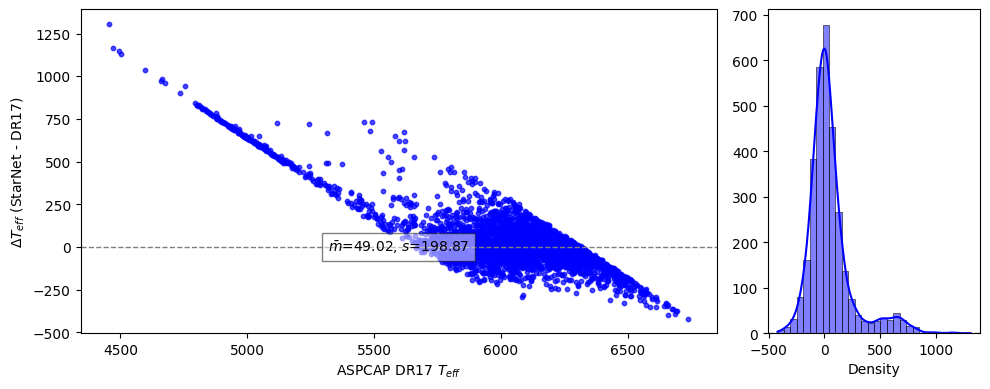

In [18]:
#plot residu teff 5

plot_residu(residu_5,y_val,'teff')


In [ ]:
mse,rsme,r2 = mse_rsme(residu_5,'teff')
print(f"MSE Teff n = 5: {mse}")
print(f"RSME Teff n = 5: {rsme}")
print(f"R^2 Teff n = 5: {r2}")

MSE Teff n = 5: 41951.46559313157
RSME Teff n = 5: 204.82056926278565


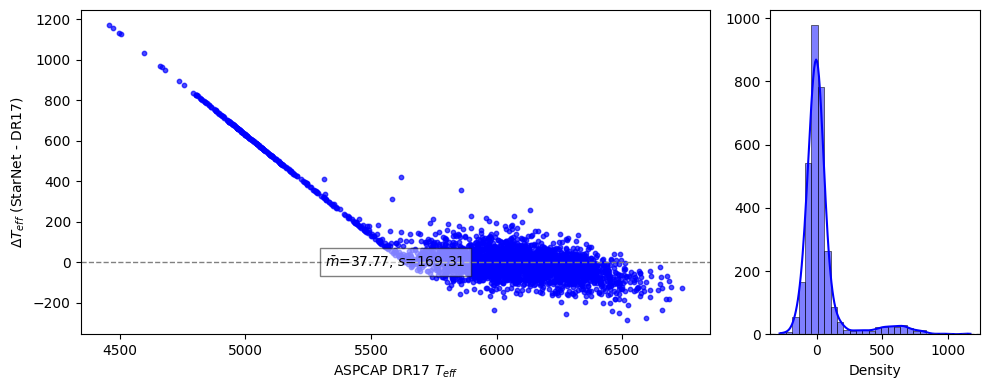

In [20]:
#plot residu teff 10

plot_residu(residu_10,y_val,'teff')

In [ ]:
mse_10,rsme_10,r2_10 = mse_rsme(residu_10,'teff')
print(f"MSE Teff n = 10: {mse_10}")
print(f"RSME Teff n = 10: {rsme_10}")
print(f"R^2 Teff n = 10: {r2_10}")

MSE Teff n = 10: 30094.1408172959
RSME Teff n = 5: 173.47662902332377


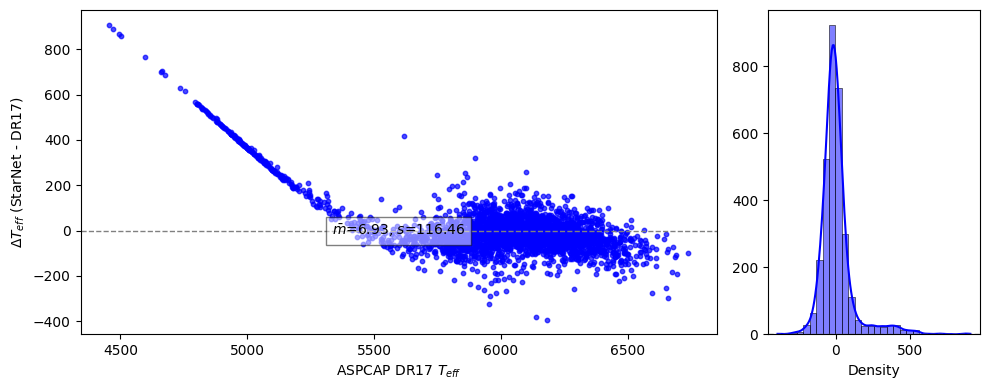

In [22]:
#plot residu teff 15

plot_residu(residu_15,y_val,'teff')

In [ ]:
mse_15,rsme_15,r2_15 = mse_rsme(residu_15,'teff')
print(f"MSE Teff n = 15: {mse_15}")
print(f"RSME Teff n = 15: {rsme_15}")
print(f"R^2 Teff n = 15: {r2_15}")

MSE Teff n = 15: 13611.49073279469
RSME Teff n = 15: 116.66829360539516


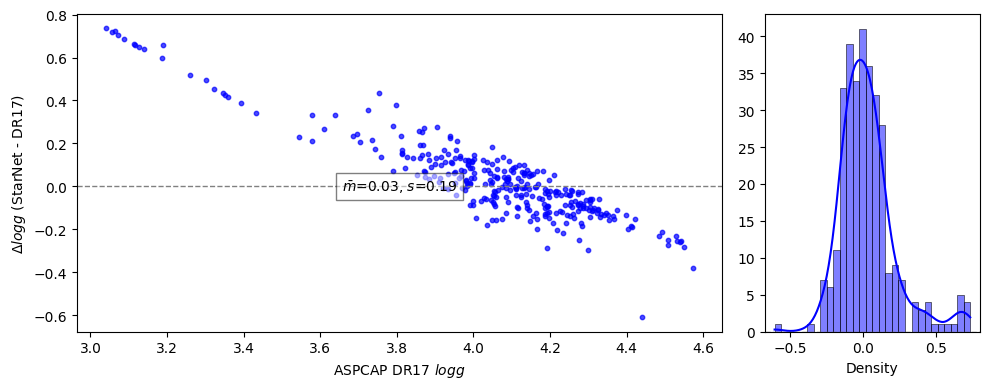

In [24]:
#plot residu logg 5
sub = 10
plot_residu(residu_5[::sub],y_val[::sub],'log_g')

In [ ]:
mse_5_log_g,rsme_5_log_g, r2_log_g_5 = mse_rsme(residu_5,'log_g')
print(f"MSE log g n = 5: {mse_5_log_g}")
print(f"RSME log g n = 5: {rsme_5_log_g}")
print(f"R^2 log g n = 5: {r2_log_g_5}")

MSE log g n = 5: 0.03560093982147676
RSME log g n = 5: 0.18868211314662756


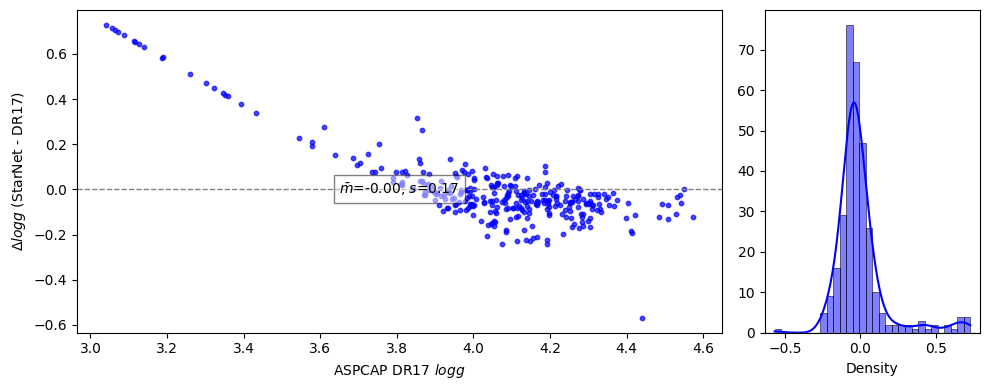

In [26]:
#plot residu logg 10
plot_residu(residu_10[::sub],y_val[::sub],'log_g')

In [ ]:
mse_10_log_g,rsme_10_log_g,r2_10_log_g = mse_rsme(residu_10,'log_g')
print(f"MSE log g n = 5: {mse_10_log_g}")
print(f"RSME log g n = 5: {rsme_10_log_g}")
print(f"R^2 log g n = 5: {r2_10_log_g}")

MSE log g n = 5: 0.02630112629751315
RSME log g n = 5: 0.16217621988908593


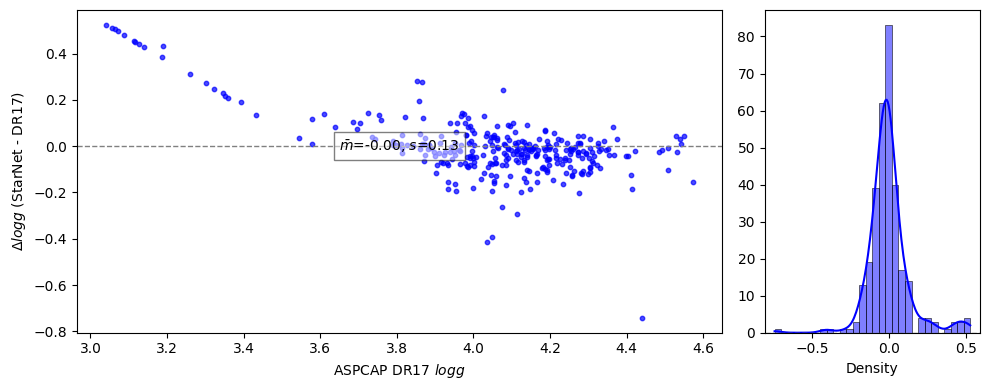

In [28]:
#plot residu logg 15
plot_residu(residu_15[::sub],y_val[::sub],'log_g')

In [ ]:
mse_15_log_g,rsme_15_log_g, r2_15_log_g = mse_rsme(residu_15,'log_g')
print(f"MSE log g n = 15: {mse_15_log_g}")
print(f"RSME log g n = 15: {rsme_15_log_g}")
print(f"R^2 log g n = 15: {r2_15_log_g}")

MSE log g n = 5: 0.015581819500578643
RSME log g n = 5: 0.1248271585055858


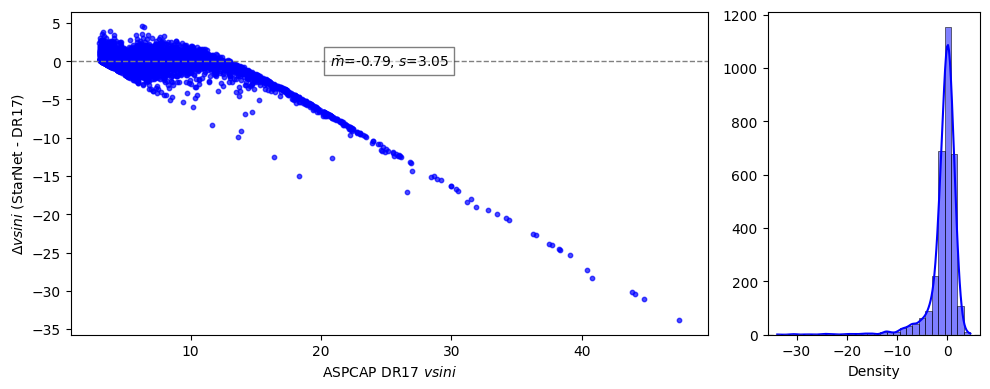

In [30]:
#plot residu vsini 5
plot_residu(residu_5,y_val,'vsini')

In [ ]:
mse_5_v_sin_i,rsme_5_v_sin_i, r2_5_v_sin_i = mse_rsme(residu_5,'vsini')
print(f"MSE v sin i n = 5: {mse_5_v_sin_i}")
print(f"RSME v sin i n = 5: {rsme_5_v_sin_i}")
print(f"R^2 v sin i n = 5: {r2_5_v_sin_i}")

MSE v sin i n = 5: 9.918652142115187
RSME v sin i n = 5: 3.1493891696827796


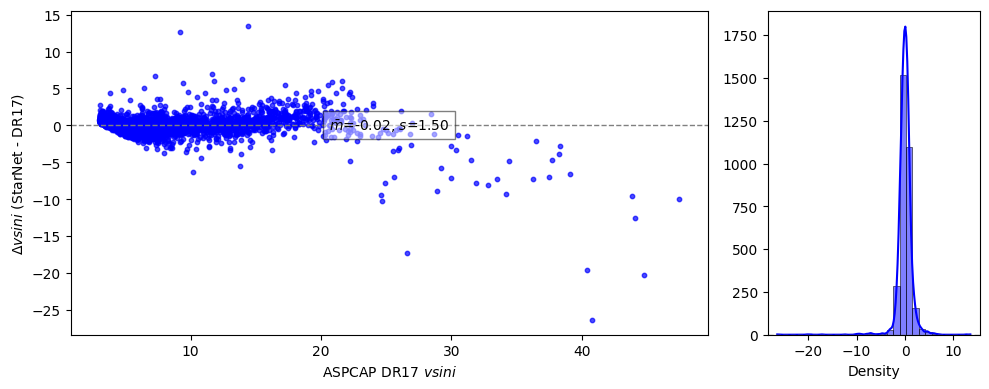

In [32]:
#plot residu vsini 10
plot_residu(residu_10,y_val,'vsini')

In [ ]:
mse_10_v_sin_i,rsme_10_v_sin_i, r2_10_v_sin_i = mse_rsme(residu_10,'vsini')
print(f"MSE v sin i n = 10: {mse_10_v_sin_i}")
print(f"RSME v sin i n = 10: {rsme_10_v_sin_i}")
print(f"R^2 v sin i n = 10: {r2_10_v_sin_i}")

MSE v sin i n = 10: 2.2623368787312064
RSME v sin i n = 10: 1.504106671327272


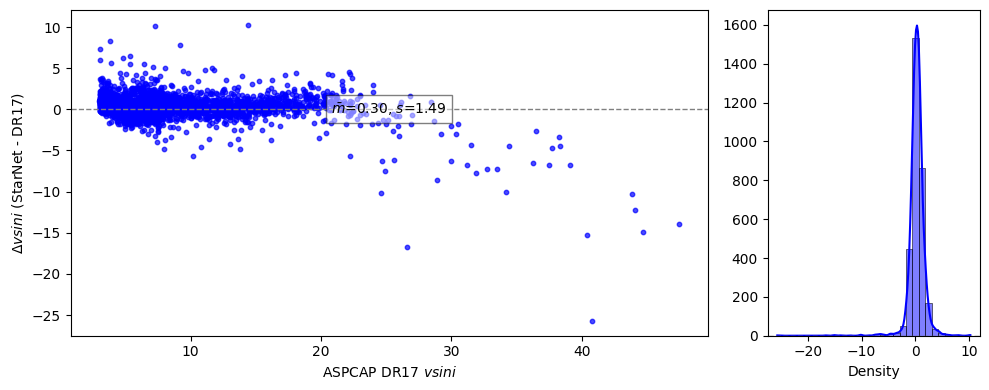

In [34]:
#plot residu vsini 15
plot_residu(residu_15,y_val,'vsini')

In [ ]:
mse_15_v_sin_i,rsme_15_v_sin_i,r2_15_v_sin_i = mse_rsme(residu_15,'vsini')
print(f"MSE v sin i n = 15: {mse_15_v_sin_i}")
print(f"RSME v sin i n = 15: {rsme_15_v_sin_i}")
print(f"R^2 v sin i n = 15: {r2_15_v_sin_i}")

MSE v sin i n = 15: 2.311464745047074
RSME v sin i n = 15: 1.5203502047380644


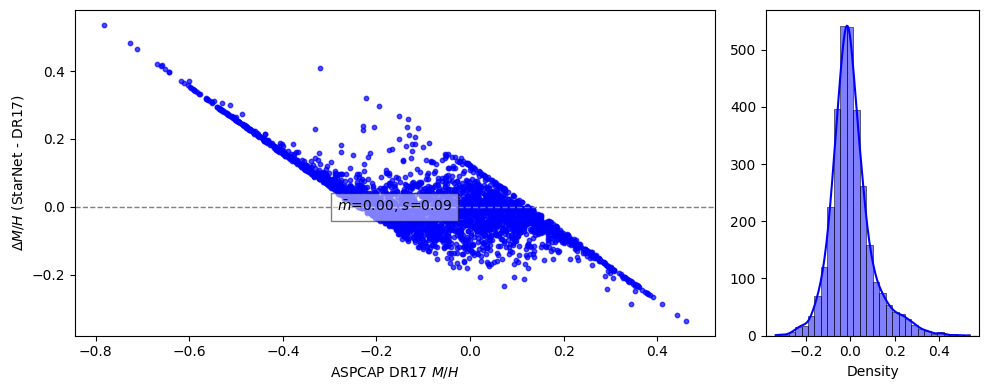

In [36]:
#plot residu  metalisitas 5
plot_residu(residu_5,y_val,'metal')

In [ ]:
mse_5_metal,rsme_5_metal, r2_5_metal = mse_rsme(residu_5,'metal')
print(f"MSE M/H n = 5: {mse_5_metal}")
print(f"RSME M/H n = 5: {rsme_5_metal}")
print(f"R^2 M/H n = 5: {r2_5_metal}")

MSE M/H n = 5: 0.009020353450367603
RSME M/H n = 5: 0.09497554132705747


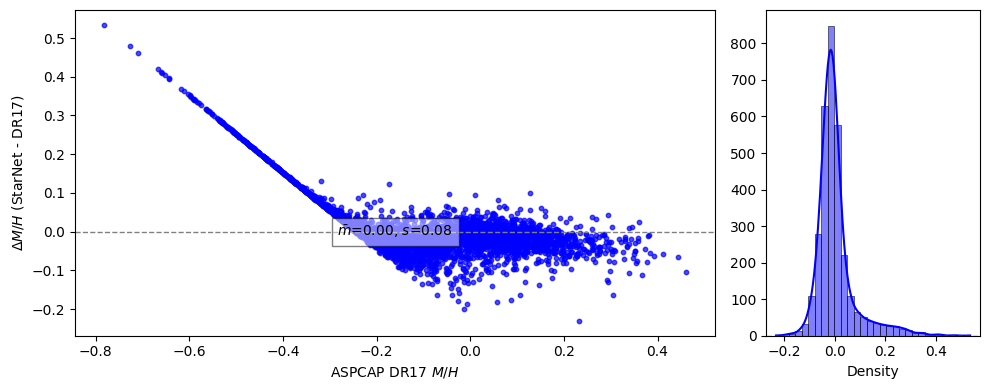

In [38]:
#plot residu  metalisitas 10
plot_residu(residu_10,y_val,'metal')

In [ ]:
mse_10_metal,rsme_10_metal, r2_10_metal = mse_rsme(residu_10,'metal')
print(f"MSE M/H n = 10: {mse_10_metal}")
print(f"RSME M/H n = 10: {rsme_10_metal}")
print(f"R^2 M/H n = 10: {r2_10_metal}")

MSE M/H n = 10: 0.005750154009194326
RSME M/H n = 10: 0.07582976994027034


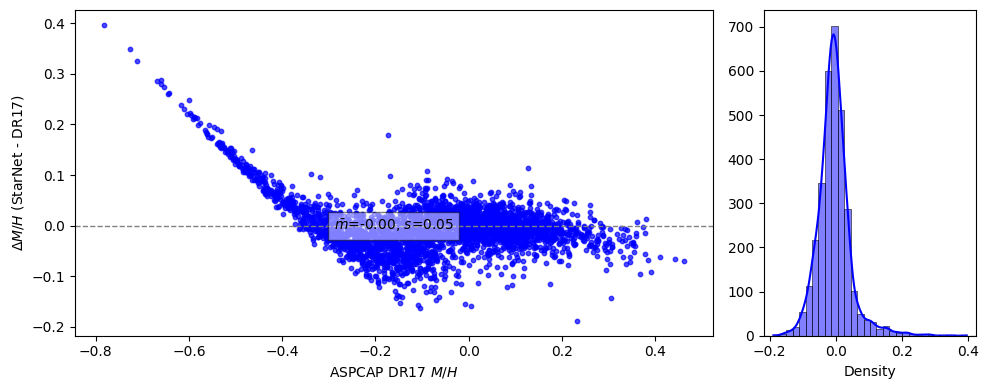

In [40]:
#plot residu  metalisitas 15
plot_residu(residu_15,y_val,'metal')

In [ ]:
mse_15_metal,rsme_15_metal, r2_15_metal = mse_rsme(residu_15,'metal')
print(f"MSE M/H n = 15: {mse_15_metal}")
print(f"RSME M/H n = 15: {rsme_15_metal}")
print(f"R^2 M/H n = 15: {r2_15_metal}")

MSE M/H n = 15: 0.0025846004705582758
RSME M/H n = 15: 0.05083896606500053


SNR < 200

In [42]:
#dapatkan data x dan y dimana x adalah flux dan y adalah vektor teff, logg, feh dan vin sin 1
"""
query
SELECT TOP 5000 *
FROM apogeeStar at INNER JOIN 
aspcapStar asr ON at.apogee_id = asr.apogee_id
where at.starflag = 0 
and at.vscatter < 1 and at.rv_logg != -9999 and at.SNR <= 200 and asr.aspcapflag =0
and asr.vsini != -9999 and at.telescope = 'apo25m' and m_h != -9999

"""
name_file_1 = 'sdss_spectra_data_bintang_apogee_low_SNR.csv'
name_file_2 = 'file_id_low_snr.csv'
folder_path = 'spectra_images_apogee_low_SNR'

x_low, y_low, wavelength_low = inputx_outputy(name_file_1, name_file_2, folder_path,untuk='train')
x_val_low, y_val_low, wavelength_val_low = inputx_outputy(name_file_1, name_file_2, folder_path, untuk='test')
#interpolasi nilai nan
for i in range(len(x_low)):
    x_low[i] = interpolate_nan(x_low[i])
    x_low[i] = normalize_flux_median(x_low[i],wavelength_low[i])

for i in range(len(x_val_low)):
    x_val_low[i] = interpolate_nan(x_val_low[i])
    x_val_low[i] = normalize_flux_median(x_val_low[i],wavelength_val_low[i])
    
mean_y_low,std_y_low = mean_std(y_low)   
y_low = standarize_output(y_low)

#split data menjadi data latih dan data uji
X_train_low, X_test_low, y_train_low, y_test_low = train_test_split(x_low, y_low, test_size=0.2, random_state=42)
#X_train_cnn, X_test_cnn,y_train_cnn,y_test_cnn = train_test_split(X_train,y_train, test_size=0.2,random_state=22)

In [43]:
starnet_5_low = StarNet(X_train_low,y_train_low,X_test_low,y_test_low)
starnet_10_low = StarNet(X_train_low,y_train_low,X_test_low,y_test_low)
starnet_15_low = StarNet(X_train_low,y_train_low,X_test_low,y_test_low)

In [44]:
#train komodo_5
starnet_5_low.arsitektur_start_net(X_train_low, y_train_low, X_test_low, y_test_low, kom_5_parameter[0],kom_5_parameter[1],kom_5_parameter[2],kom_5_parameter[3],kom_5_parameter[4],kom_5_parameter[5],kom_5_parameter[6],kom_5_parameter[7],kom_5_parameter[8],kom_5_parameter[9],kom_5_parameter[10],kom_5_parameter[11],kom_5_parameter[12],kom_5_parameter[13],kom_5_parameter[14],kom_5_parameter[15])
hist_5_low = starnet_5_low.history
model_5_low = starnet_5_low.model

Epoch 1/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 231ms/step - loss: 1.1433 - val_loss: 0.8225
Epoch 2/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step - loss: 1.0189 - val_loss: 0.8041
Epoch 3/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step - loss: 0.9932 - val_loss: 0.8063
Epoch 4/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step - loss: 1.1292 - val_loss: 0.8065
Epoch 5/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 192ms/step - loss: 1.0897 - val_loss: 0.7981
Epoch 6/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 190ms/step - loss: 0.9565 - val_loss: 0.8032
Epoch 7/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step - loss: 0.9227 - val_loss: 0.7928
Epoch 8/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - loss: 0.9887 - val_loss: 0.7864
Epoch 9/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 192ms/step - loss: 1.0060 - val_loss: 0.7662
Epoch 10/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 194ms/step - loss: 0.9636 - val_loss: 0.7404
Epoch 11/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 194ms/step - loss: 0.8661 - val_loss: 0.7055
Epoch 12/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 234ms/step

In [45]:
#train komodo_10
starnet_10_low.arsitektur_start_net(X_train_low, y_train_low, X_test_low, y_test_low, kom_10_parameter[0],kom_10_parameter[1],kom_10_parameter[2],kom_10_parameter[3],kom_10_parameter[4],kom_10_parameter[5],kom_10_parameter[6],kom_10_parameter[7],kom_10_parameter[8],kom_10_parameter[9],kom_10_parameter[10],kom_10_parameter[11],kom_10_parameter[12],kom_10_parameter[13],kom_10_parameter[14],kom_10_parameter[15])
hist_10_low = starnet_10_low.history
model_10_low = starnet_10_low.model

Epoch 1/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 111s 189ms/step - loss: 1.3342 - val_loss: 0.8097
Epoch 2/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 108s 189ms/step - loss: 1.0520 - val_loss: 0.8430
Epoch 3/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 108s 190ms/step - loss: 1.1773 - val_loss: 0.8507
Epoch 4/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 142s 188ms/step - loss: 1.0131 - val_loss: 0.8738
Epoch 5/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 109s 190ms/step - loss: 1.0835 - val_loss: 0.8624
Epoch 6/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 111s 193ms/step - loss: 1.0668 - val_loss: 0.8059
Epoch 7/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 139s 187ms/step - loss: 1.1196 - val_loss: 0.8514
Epoch 8/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 140s 184ms/step - loss: 1.0630 - val_loss: 0.8443
Epoch 9/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 143s 185ms/step - loss: 1.0319 - val_loss: 0.8081
Epoch 10/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 107s 187ms/step - loss: 1.0532 - val_loss: 0.8063
Epoch 11/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 141s 185ms/step - loss: 1.0747 - val_loss: 0.8147
Epoch 12

In [46]:
#train komodo_15
starnet_15_low.arsitektur_start_net(X_train_low, y_train_low, X_test_low, y_test_low, kom_15_parameter[0],kom_15_parameter[1],kom_15_parameter[2],kom_15_parameter[3],kom_15_parameter[4],kom_15_parameter[5],kom_15_parameter[6],kom_15_parameter[7],kom_15_parameter[8],kom_15_parameter[9],kom_15_parameter[10],kom_15_parameter[11],kom_15_parameter[12],kom_15_parameter[13],kom_15_parameter[14],kom_15_parameter[15])
hist_15_low = starnet_15_low.history
model_15_low = starnet_15_low.model

Epoch 1/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - loss: 1.2440 - val_loss: 0.8069
Epoch 2/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 171ms/step - loss: 1.1185 - val_loss: 0.8307
Epoch 3/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 169ms/step - loss: 0.9427 - val_loss: 0.8437
Epoch 4/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 173ms/step - loss: 1.0972 - val_loss: 0.8139
Epoch 5/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 169ms/step - loss: 1.1766 - val_loss: 0.8096
Epoch 6/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 173ms/step - loss: 1.1564 - val_loss: 0.8190
Epoch 7/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 171ms/step - loss: 1.0260 - val_loss: 0.7925
Epoch 8/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 174ms/step - loss: 0.9172 - val_loss: 0.7502
Epoch 9/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 172ms/step - loss: 0.8852 - val_loss: 0.5147
Epoch 10/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 161ms/step - loss: 0.6841 - val_loss: 0.4324
Epoch 11/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 167ms/step - loss: 0.5900 - val_loss: 0.4216
Epoch 12/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 12

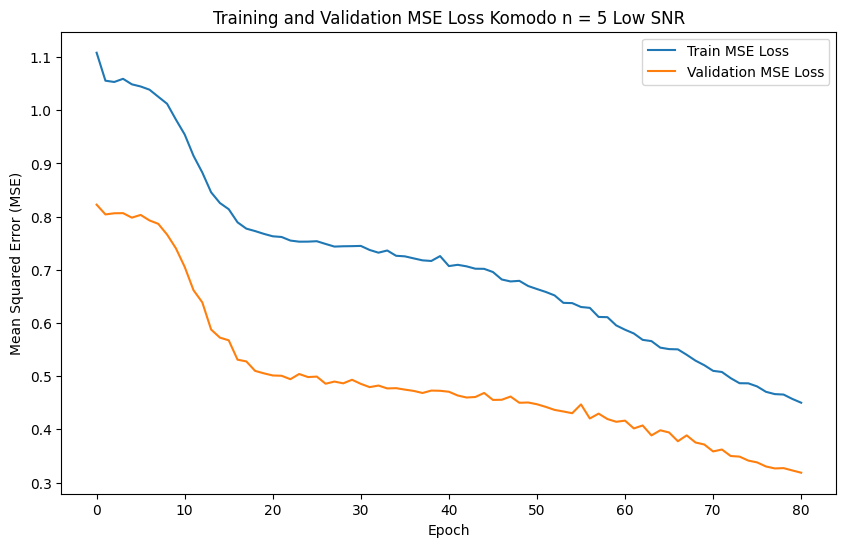

In [47]:
# plot train_valid komodo 5

plt.figure(figsize=(10, 6))
plt.plot(hist_5_low.history['loss'], label='Train MSE Loss')
plt.plot(hist_5_low.history['val_loss'], label='Validation MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Validation MSE Loss Komodo n = 5 Low SNR')
plt.legend()
plt.show()

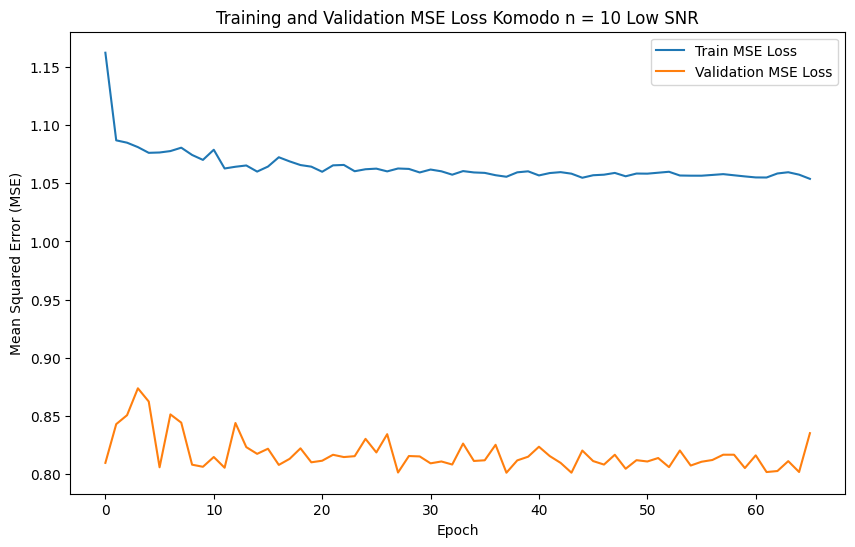

In [48]:
# plot train_valid komodo 10

plt.figure(figsize=(10, 6))
plt.plot(hist_10_low.history['loss'], label='Train MSE Loss')
plt.plot(hist_10_low.history['val_loss'], label='Validation MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Validation MSE Loss Komodo n = 10 Low SNR')
plt.legend()
plt.show()

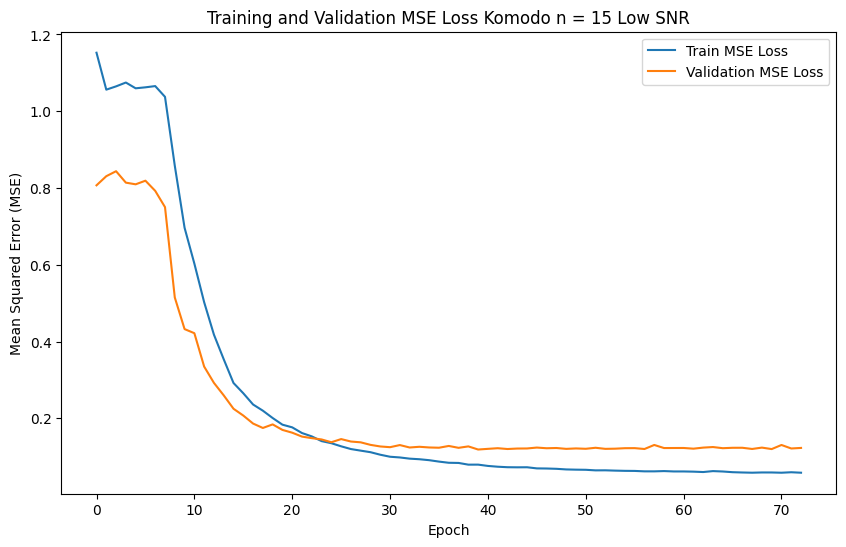

In [49]:
# plot train_valid komodo 15

plt.figure(figsize=(10, 6))
plt.plot(hist_15_low.history['loss'], label='Train MSE Loss')
plt.plot(hist_15_low.history['val_loss'], label='Validation MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Validation MSE Loss Komodo n = 15 Low SNR')
plt.legend()
plt.show()

In [50]:
y_pred_5_low = model_5_low.predict(x_val_low)
y_pred_10_low = model_10_low.predict(x_val_low)
y_pred_15_low = model_15_low.predict(x_val_low)

y_pred_5_low = decode_pred(y_pred_5_low,mean_y_low,std_y_low)
y_pred_10_low = decode_pred(y_pred_10_low,mean_y_low,std_y_low)
y_pred_15_low = decode_pred(y_pred_15_low,mean_y_low,std_y_low)

90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step


In [51]:
y_pred_5 = model_5.predict(x_val)
y_pred_10 = model_10.predict(x_val)
y_pred_15 = model_15.predict(x_val)

y_pred_5 = decode_pred(y_pred_5,mean_y,std_y)
y_pred_10 = decode_pred(y_pred_10,mean_y,std_y)
y_pred_15 = decode_pred(y_pred_15,mean_y,std_y)

99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step


In [52]:
#nilai residual
residu_5_low = y_pred_5_low - y_val_low
residu_10_low = y_pred_10_low - y_val_low
residu_15_low = y_pred_15_low - y_val_low

#nilai mse dan rmse
mse_5_low = np.mean(np.square(residu_5_low))
mse_10_low = np.mean(np.square(residu_10_low))
mse_15_low = np.mean(np.square(residu_15_low))

rmse_5_low = np.sqrt(mse_5_low)
rmse_10_low = np.sqrt(mse_10_low)
rmse_15_low = np.sqrt(mse_15_low)

print(f'MSE Komodo n = 5 : {mse_5_low}')
print(f'MSE Komodo n = 10 : {mse_10_low}')
print(f'MSE Komodo n = 15 : {mse_15_low}')

print(f'RMSE Komodo n = 5 : {rmse_5_low}')
print(f'RMSE Komodo n = 10 : {rmse_10_low}')
print(f'RMSE Komodo n = 15 : {rmse_15_low}')


MSE Komodo n = 5 : 11255.422464778996
MSE Komodo n = 10 : 31845.606202630825
MSE Komodo n = 15 : 3277.3097153404633
RMSE Komodo n = 5 : 106.09157584266055
RMSE Komodo n = 10 : 178.45337262890502
RMSE Komodo n = 15 : 57.24779223114603


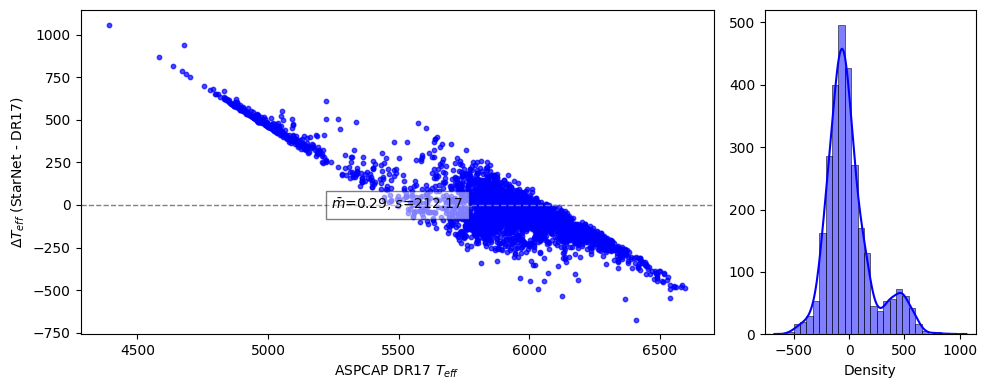

In [53]:
#plot residu teff 5

plot_residu(residu_5_low,y_val_low,'teff')

In [54]:
mse_5_teff_low,rsme_5_teff_low = mse_rsme(residu_5_low,'teff')
print(f"MSE teff low n = 5: {mse_5_teff_low}")
print(f"RSME teff low n = 5: {rsme_5_teff_low}")

MSE teff low n = 5: 45014.15735454672
RSME teff low n = 5: 212.16540093650218


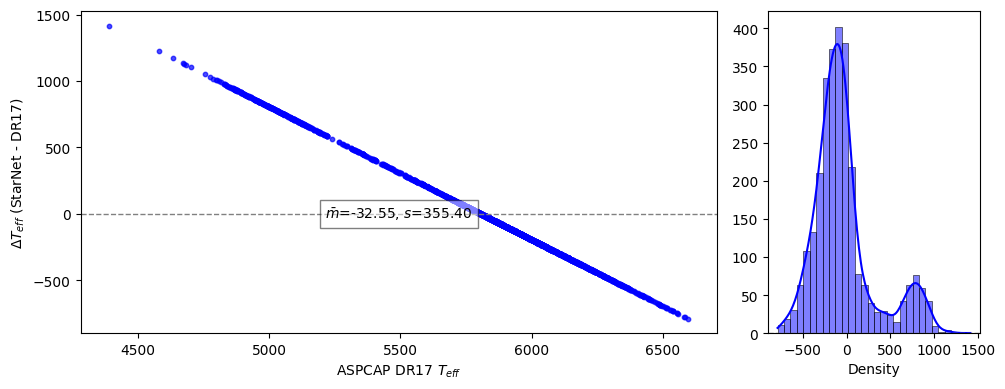

In [55]:
#plot residu teff 10

plot_residu(residu_10_low,y_val_low,'teff')

In [56]:
mse_10_teff_low,rsme_10_teff_low = mse_rsme(residu_10_low,'teff')
print(f"MSE teff low n = 10: {mse_10_teff_low}")
print(f"RSME teff low n = 10: {rsme_10_teff_low}")

MSE teff low n = 10: 127367.58498579552
RSME teff low n = 10: 356.8859551534573


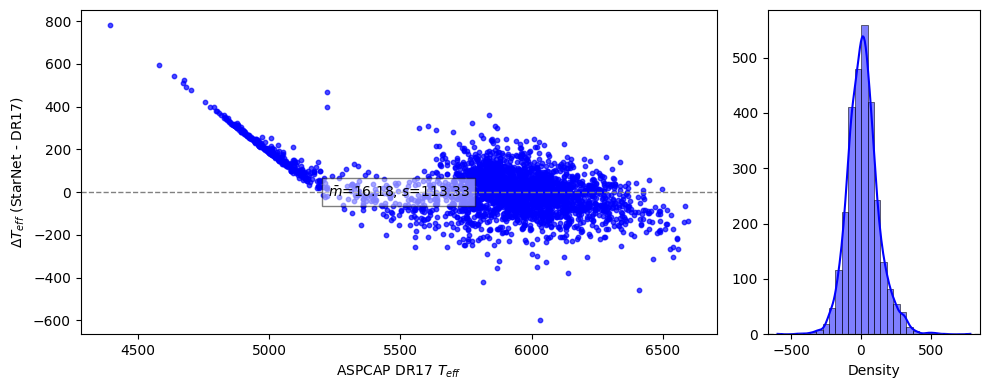

In [57]:
#plot residu teff 15

plot_residu(residu_15_low,y_val_low,'teff')

In [58]:
mse_15_teff_low,rsme_15_teff_low = mse_rsme(residu_15_low,'teff')
print(f"MSE teff low n = 15: {mse_15_teff_low}")
print(f"RSME teff low n = 15: {rsme_15_teff_low}")

MSE teff low n = 15: 13106.26267457178
RSME teff low n = 15: 114.48258677446007


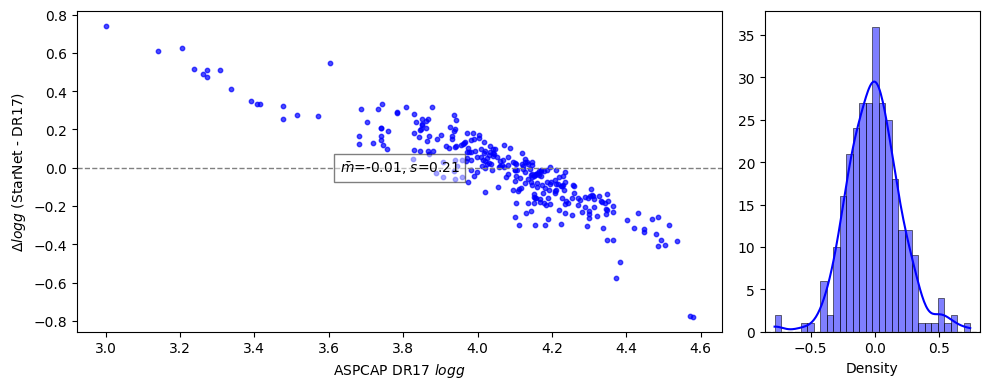

In [59]:
#plot residu logg 5
sub = 10
plot_residu(residu_5_low[::sub],y_val_low[::sub],'log_g')

In [60]:
mse_5_logg_low,rsme_5_logg_low = mse_rsme(residu_5_low,'log_g')
print(f"MSE log g low n = 5: {mse_5_logg_low}")
print(f"RSME log g low n = 5: {rsme_5_logg_low}")

MSE log g low n = 5: 0.05942100257202808
RSME log g low n = 5: 0.24376423562948704


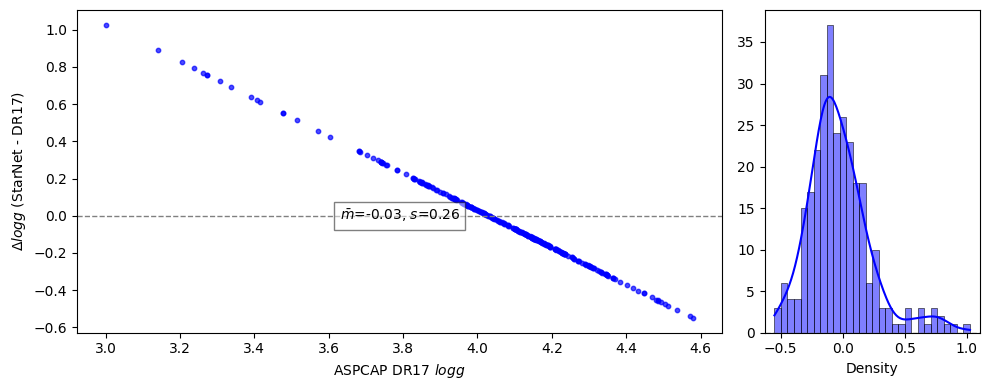

In [61]:
#plot residu logg 10
plot_residu(residu_10_low[::sub],y_val_low[::sub],'log_g')

In [62]:
mse_10_logg_low,rsme_10_logg_low = mse_rsme(residu_10_low,'log_g')
print(f"MSE log g low n = 10: {mse_10_logg_low}")
print(f"RSME log g low n = 10: {rsme_10_logg_low}")

MSE log g low n = 10: 0.097017723739637
RSME log g low n = 10: 0.31147668249748167


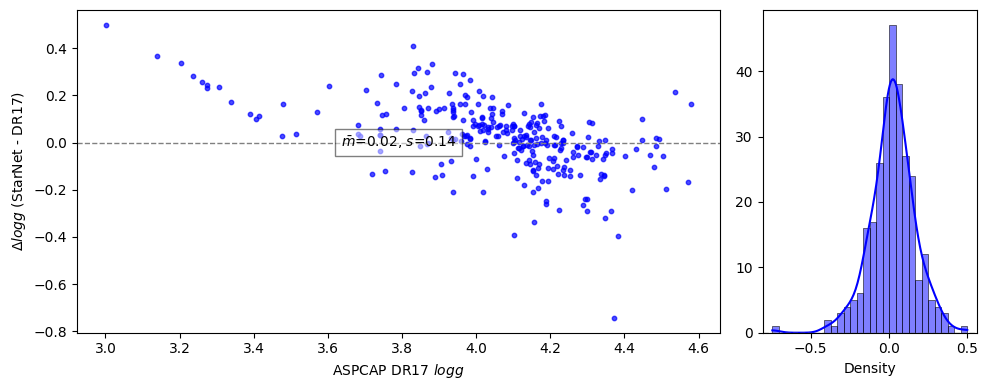

In [63]:
#plot residu logg 15
plot_residu(residu_15_low[::sub],y_val_low[::sub],'log_g')

In [64]:
mse_15_logg_low,rsme_15_logg_low = mse_rsme(residu_15_low,'log_g')
print(f"MSE log g low n = 15: {mse_15_logg_low}")
print(f"RSME log g low n = 15: {rsme_15_logg_low}")

MSE log g low n = 15: 0.02666190071156982
RSME log g low n = 15: 0.16328472283581774


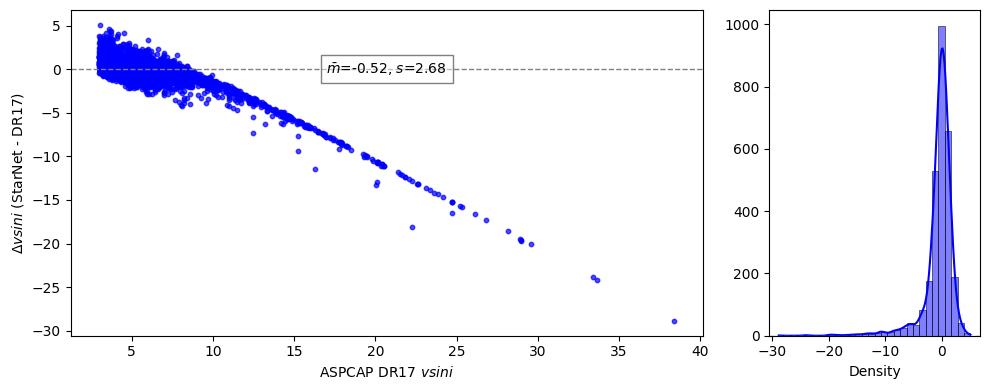

In [65]:
#plot residu vsini 5
plot_residu(residu_5_low,y_val_low,'vsini')

In [66]:
mse_5_vsini_low,rsme_5_vsini_low = mse_rsme(residu_5_low,'vsini')
print(f"MSE v sin i low n = 5: {mse_5_vsini_low}")
print(f"RSME v sin i low n = 5: {rsme_5_vsini_low}")

MSE v sin i low n = 5: 7.458993586550979
RSME v sin i low n = 5: 2.7311158134636067


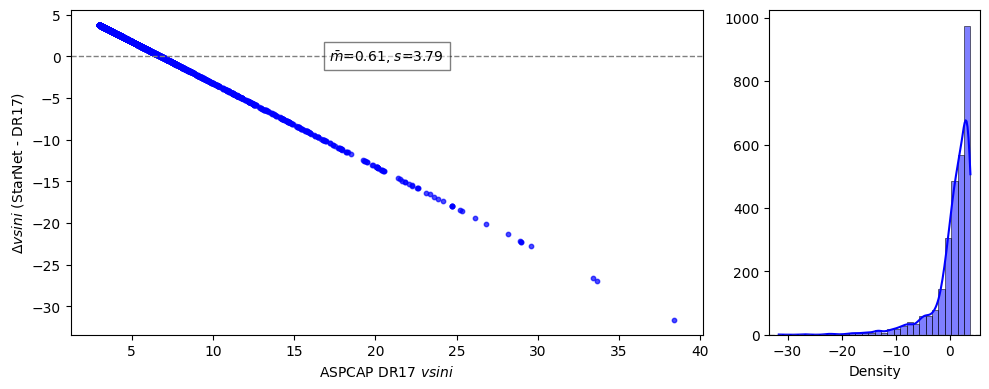

In [67]:
#plot residu vsini 10
plot_residu(residu_10_low,y_val_low,'vsini')

In [68]:
mse_10_vsini_low,rsme_10_vsini_low = mse_rsme(residu_10_low,'vsini')
print(f"MSE v sin i low n = 10: {mse_10_vsini_low}")
print(f"RSME v sin i low n = 10: {rsme_10_vsini_low}")

MSE v sin i low n = 10: 14.701547522323429
RSME v sin i low n = 10: 3.834259709816672


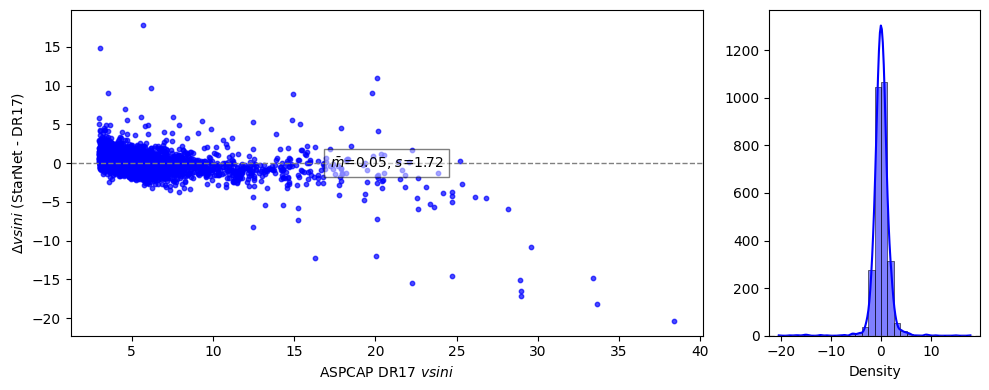

In [69]:
#plot residu vsini 15
plot_residu(residu_15_low,y_val_low,'vsini')

In [70]:
mse_15_vsini_low,rsme_15_vsini_low = mse_rsme(residu_15_low,'vsini')
print(f"MSE v sin i low n = 15: {mse_15_vsini_low}")
print(f"RSME v sin i low n = 15: {rsme_15_vsini_low}")

MSE v sin i low n = 15: 2.9443101273172765
RSME v sin i low n = 15: 1.7158992182868074


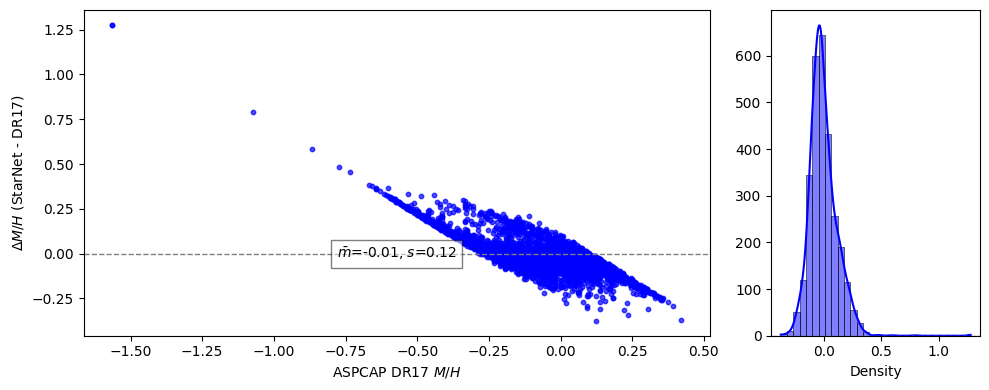

In [71]:
#plot residu  metalisitas 5
plot_residu(residu_5_low,y_val_low,'metal')

In [72]:
mse_5_metal_low,rsme_5_metal_low = mse_rsme(residu_5_low,'metal')
print(f"MSE M/H low n = 5: {mse_5_metal_low}")
print(f"RSME M/H low n = 5: {rsme_5_metal_low}")

MSE M/H low n = 5: 0.014089980139383429
RSME M/H low n = 5: 0.11870122214780869


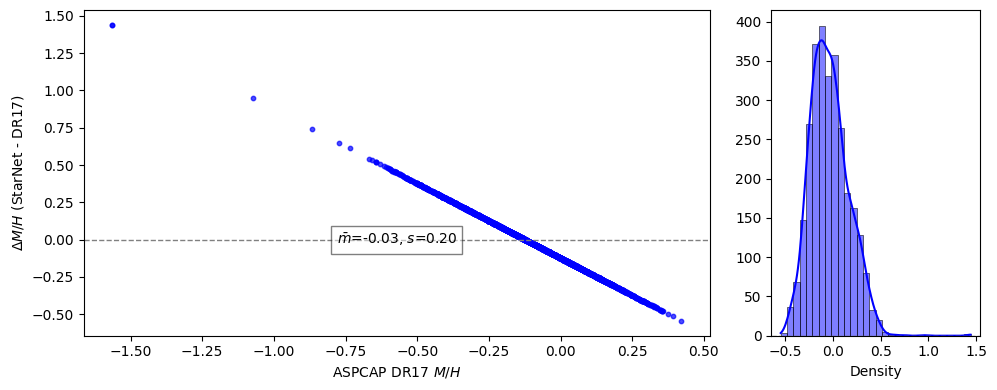

In [73]:
#plot residu  metalisitas 10
plot_residu(residu_10_low,y_val_low,'metal')

In [74]:
mse_10_metal_low,rsme_10_metal_low = mse_rsme(residu_10_low,'metal')
print(f"MSE M/H low n = 10: {mse_10_metal_low}")
print(f"RSME M/H low n = 10: {rsme_10_metal_low}")

MSE M/H low n = 10: 0.041259481720422916
RSME M/H low n = 10: 0.20312430115676194


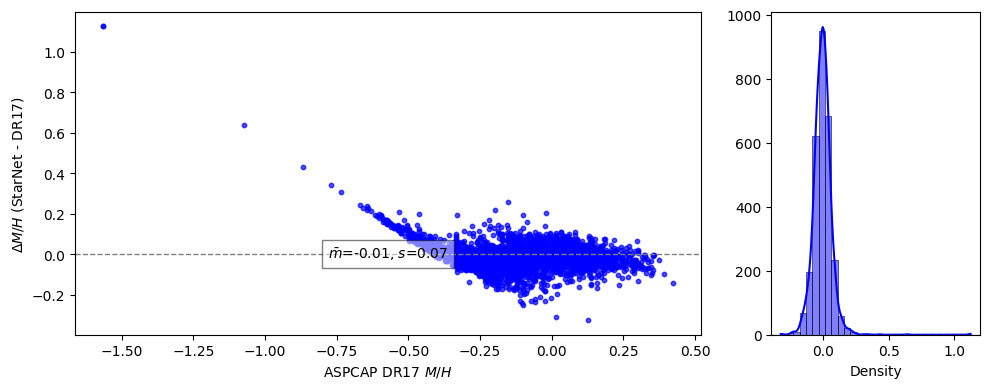

In [75]:
#plot residu  metalisitas 15
plot_residu(residu_15_low,y_val_low,'metal')

In [76]:
mse_15_metal_low,rsme_15_metal_low = mse_rsme(residu_15_low,'metal')
print(f"MSE M/H low n = 15: {mse_15_metal_low}")
print(f"RSME M/H low n = 15: {rsme_15_metal_low}")

MSE M/H low n = 15: 0.005214762040607847
RSME M/H low n = 15: 0.0722133093038108


In [77]:
#Starnet default 

models = Sequential()
        
models.add(Input(shape=(8575, 1)))

# Conv Layer 1
models.add(Conv1D(filters=4,kernel_size=16, activation='relu', kernel_initializer='he_normal'))

# Conv Layer 2
models.add(Conv1D(filters=16,kernel_size=32, activation='relu', kernel_initializer='he_normal'))

# Max Pooling
models.add(MaxPooling1D(pool_size=(4,)))

# Flattening
models.add(Flatten())

# Fully Connected Layer 1
models.add(Dense(256, activation='relu', kernel_initializer='he_normal'))

# Fully Connected Layer 2
models.add(Dense(128, activation='relu', kernel_initializer='he_normal'))

# Output layer untuk empat parameter bintang
models.add(Dense(4))

# Kompilasi model
models.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

In [78]:
hist_ori = models.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32, verbose=1)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 301ms/step - loss: 76.6290 - val_loss: 1.0388
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 265ms/step - loss: 1.0871 - val_loss: 1.0886
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 287ms/step - loss: 1.0105 - val_loss: 0.7590
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 289ms/step - loss: 0.6808 - val_loss: 0.5425
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 289ms/step - loss: 0.5788 - val_loss: 0.5099
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 287ms/step - loss: 0.5652 - val_loss: 0.4978
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 294ms/step - loss: 0.4611 - val_loss: 0.4502
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 285ms/step - loss: 0.4372 - val_loss: 0.4504
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 288ms/step - loss: 0.4849 - val_loss: 0.4630
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 287ms/step - loss: 0.5040 - val_loss: 0.4122
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 289ms/step - loss: 0.4040 - val_loss: 0.3799
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 

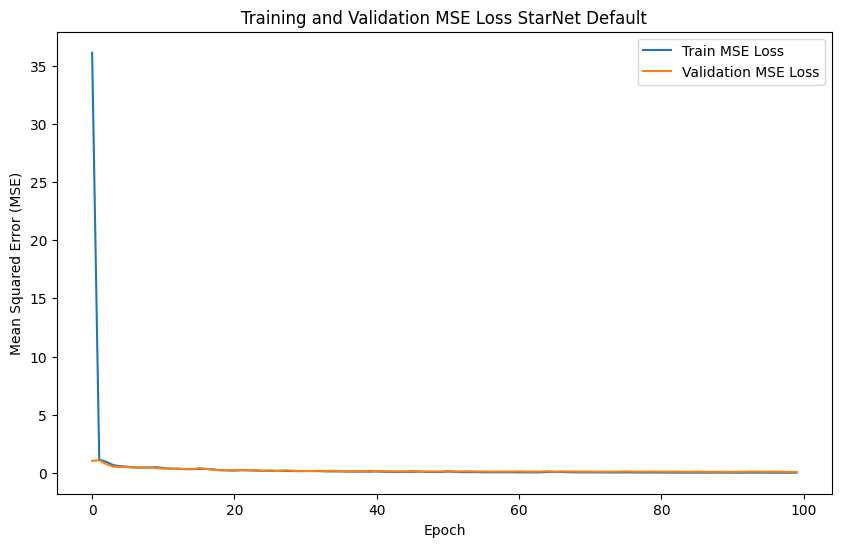

In [79]:
# plot train_valid komodo 

plt.figure(figsize=(10, 6))
plt.plot(hist_ori.history['loss'], label='Train MSE Loss')
plt.plot(hist_ori.history['val_loss'], label='Validation MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Validation MSE Loss StarNet Default')
plt.legend()
plt.show()

In [ ]:
y_predict_ori = models.predict(x_val)
y_predict_ori = decode_pred(y_predict_ori,mean_y,std_y)
residu_ori = y_predict_ori - y_val
mean_aktual = np.mean(y_val, axis = 0)

ss_ori = np.sum((residu_ori - mean_aktual)**2)

99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step


In [ ]:
#nilai mse dan rmse
mse_ori = np.mean(np.square(residu_ori))
rmse_ori = np.sqrt(mse_ori)
r2_ori = 1 - (np.sum(np.square(residu_ori)) / ss_ori)


print(f'MSE Komodo ori : {mse_ori}')

print(f'RMSE Komodo ori : {rmse_ori}')

print(f'R^2 Komodo ori : {r2_ori}')



MSE Komodo ori : 2059.5950913811625
RMSE Komodo ori : 45.382762051038306


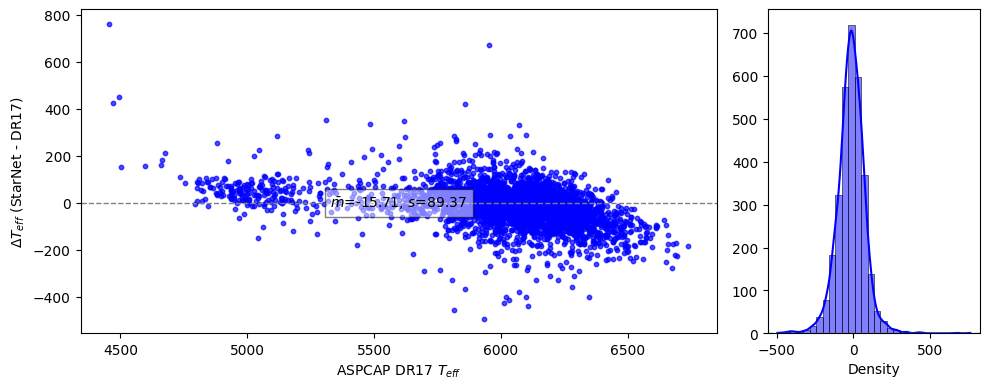

In [82]:
#plot residu teff 

plot_residu(residu_ori,y_val,'teff')

In [ ]:
mse_teff_ori,rsme_teff_ori,r2_teff_ori = mse_rsme(residu_ori,'teff')
print(f"MSE teff ori : {mse_teff_ori}")
print(f"RSME teff ori : {rsme_teff_ori}")
print(f"R^2 teff ori : {r2_teff_ori}")

MSE teff ori : 8233.373120774844
RSME teff ori : 90.73793650273763


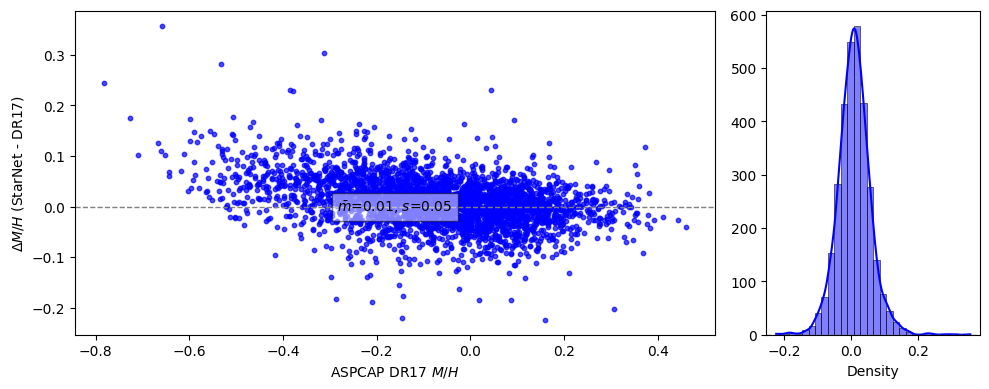

In [84]:
#plot residu  metalisitas 
plot_residu(residu_ori,y_val,'metal')

In [ ]:
mse_metal_ori,rsme_metal_ori,r2_metal_ori = mse_rsme(residu_ori,'metal')
print(f"MSE M/H ori : {mse_metal_ori}")
print(f"RSME M/H ori : {rsme_metal_ori}")
print(f"R^2 M/H ori : {r2_metal_ori}")

MSE M/H ori : 0.0025004024153162806
RSME M/H ori : 0.05000402399123775


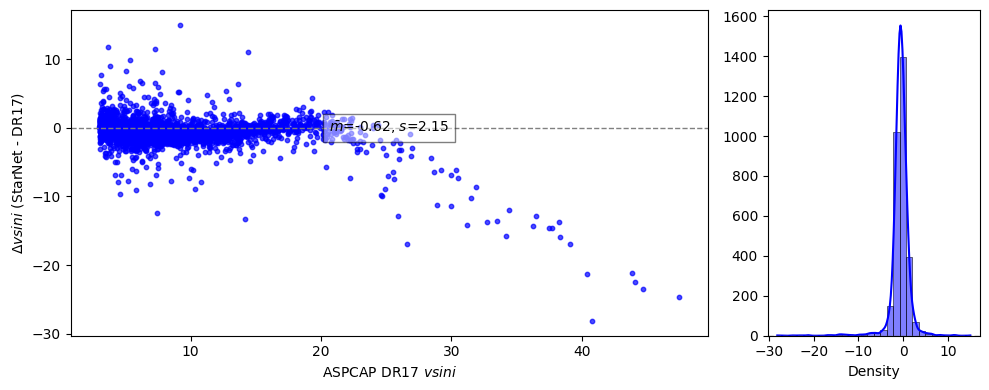

In [86]:
#plot residu vsini 
plot_residu(residu_ori,y_val,'vsini')

In [ ]:
mse_vsini_ori,rsme_vsini_ori,r2_vsini_ori = mse_rsme(residu_ori,'vsini')
print(f"MSE v sin i ori : {mse_vsini_ori}")
print(f"RSME v sin i ori : {rsme_vsini_ori}")
print(f"R^2 v sin i ori : {r2_vsini_ori}")

MSE v sin i ori : 4.986431630268181
RSME v sin i ori : 2.233031936687915


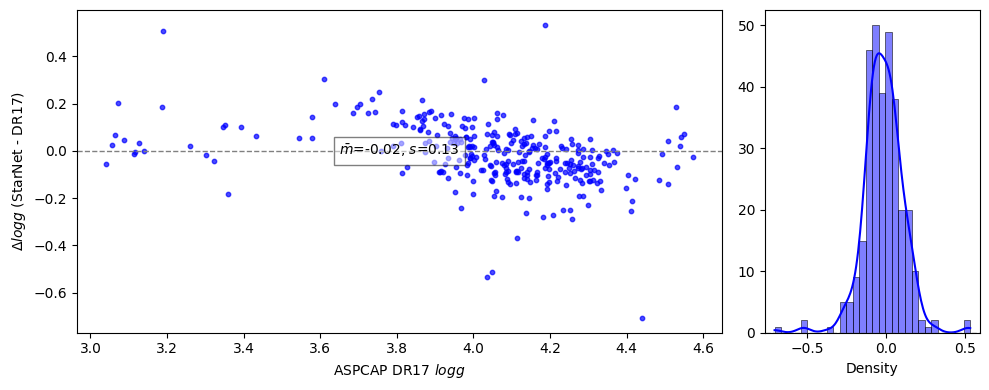

In [88]:
#plot residu logg 
sub_ori = 10
plot_residu(residu_ori[::sub_ori],y_val[::sub_ori],'log_g')

In [ ]:
mse_logg_ori,rsme_logg_ori,r2_logg_ori = mse_rsme(residu_ori,'log_g')
print(f"MSE teff ori : {mse_logg_ori}")
print(f"RSME teff ori : {rsme_logg_ori}")
print(f"R^2 teff ori : {r2_logg_ori}")

MSE teff ori : 0.018312717123596545
RSME teff ori : 0.135324488262829
